# 📊 Notebook 1: Exploratory Data Analysis

This notebook explores the **Financial News Market Events Dataset**.

We will:
- Load and inspect the raw data
- Handle missing values
- Visualize label distributions (Market Event, Sentiment, Impact Level)
- Analyze headline lengths
- Explore numerical features
- Save the cleaned dataset for model training

In [4]:
# ── Install required libraries ──────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn plotly

In [5]:
# ── Import libraries ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 📂 Step 1: Load Dataset

In [9]:
# ── Load the raw CSV dataset ─────────────────────────────────────────────────
# The dataset contains financial news headlines with labels for:
#   - Market_Event  : type of market event (20 classes)
#   - Sentiment     : Positive / Negative / Neutral
#   - Impact_Level  : High / Medium / Low

df = pd.read_csv("financial_news_events.csv")

print("Dataset Shape:", df.shape)
print("Column Names:", df.columns.tolist())
df.head()

Dataset Shape: (3024, 12)
Column Names: ['Date', 'Headline', 'Source', 'Market_Event', 'Market_Index', 'Index_Change_Percent', 'Trading_Volume', 'Sentiment', 'Sector', 'Impact_Level', 'Related_Company', 'News_Url']


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-05-21,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,3.52,166.45,NaN,Technology,High,Goldman Sachs,https://timesofindia.indiatimes.com/business/m...
1,2025-05-18,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-3.39,57.61,NaN,Retail,Low,ExxonMobil,https://timesofindia.indiatimes.com/business/m...
2,2025-06-25,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-0.05,403.22,Neutral,Retail,Medium,Boeing,https://www.moneycontrol.com/us-markets/sp-500
3,2025-07-21,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-2.29,100.11,Positive,Consumer Goods,Low,Samsung Electronics,https://www.cnbc.com/2025/09/automotive-indust...
4,2025-07-23,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-3.97,438.22,Negative,Consumer Goods,Low,JP Morgan Chase,https://www.bloomberg.com/australia/asx-200-pe...


In [11]:
# ── Check data types and missing values ──────────────────────────────────────
print("Data Types:")
print(df.dtypes)

print("Missing Values per Column:")
print(df.isnull().sum())

print("Total missing:", df.isnull().sum().sum())

Data Types:
Date                     object
Headline                 object
Source                   object
Market_Event             object
Market_Index             object
Index_Change_Percent    float64
Trading_Volume          float64
Sentiment                object
Sector                   object
Impact_Level             object
Related_Company          object
News_Url                 object
dtype: object
Missing Values per Column:
Date                      0
Headline                148
Source                    0
Market_Event              0
Market_Index              0
Index_Change_Percent    161
Trading_Volume            0
Sentiment               171
Sector                    0
Impact_Level              0
Related_Company           0
News_Url                153
dtype: int64
Total missing: 633


## 🧹 Step 2: Data Cleaning

In [12]:
# ── Drop rows where Headline or Sentiment is missing ─────────────────────────
# These are the primary input (Headline) and one of our target labels (Sentiment)
# We cannot impute text data, so we drop these rows

before = len(df)
df = df.dropna(subset=["Headline", "Sentiment"])
after = len(df)
print(f"Rows removed due to missing Headline/Sentiment: {before - after}")
print(f"Remaining rows: {after}")

Rows removed due to missing Headline/Sentiment: 310
Remaining rows: 2714


In [13]:
# ── Median imputation for numerical features ─────────────────────────────────
# Index_Change_Percent has ~161 missing values
# We fill with median to avoid skewing the distribution (robust to outliers)

median_index = df["Index_Change_Percent"].median()
df["Index_Change_Percent"] = df["Index_Change_Percent"].fillna(median_index)

print(f"Index_Change_Percent median used for imputation: {median_index:.4f}")
print("Missing values after cleaning:")
print(df[["Headline", "Sentiment", "Index_Change_Percent", "Impact_Level"]].isnull().sum())

Index_Change_Percent median used for imputation: -0.1000
Missing values after cleaning:
Headline                0
Sentiment               0
Index_Change_Percent    0
Impact_Level            0
dtype: int64


## 📈 Step 3: Label Distributions

FileNotFoundError: [Errno 2] No such file or directory: 'results/plots/label_distributions.png'

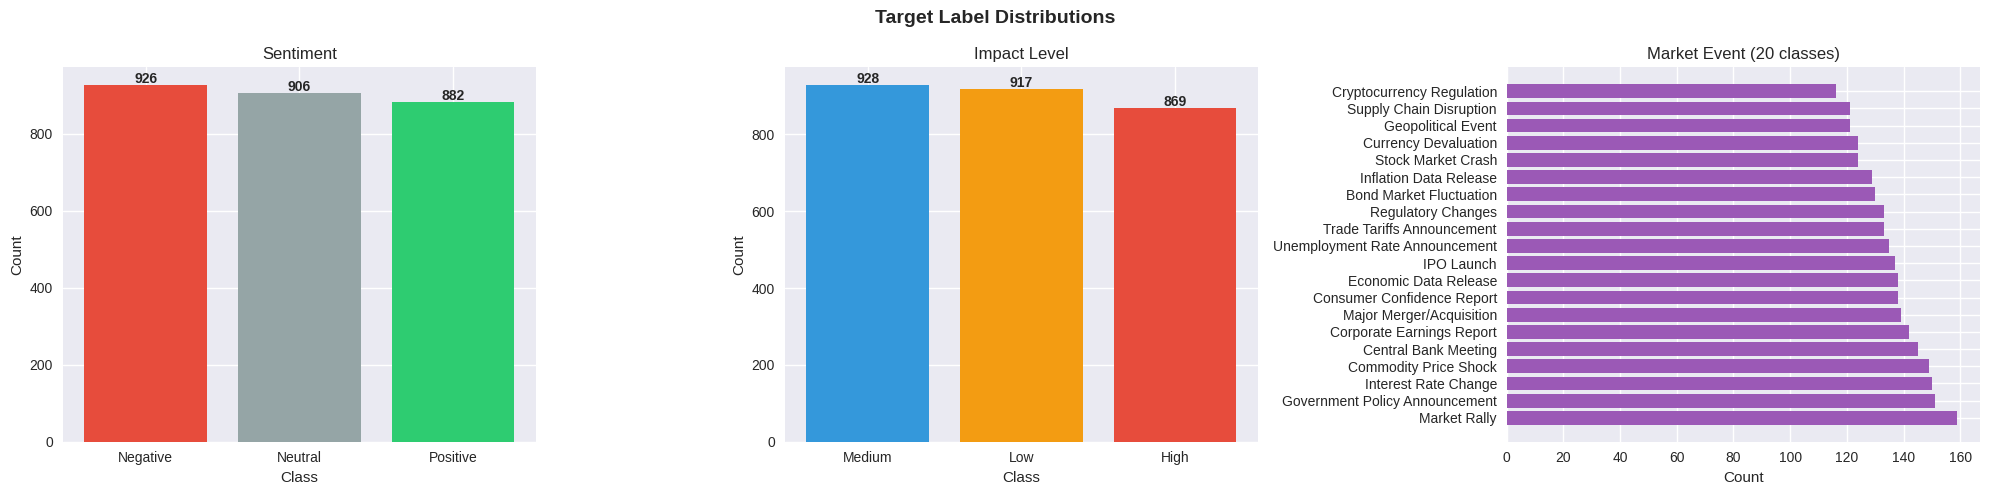

In [14]:
# ── Plot distributions for all 3 target labels ───────────────────────────────
# This helps us understand class balance before training
# Well-balanced classes = less need for SMOTE

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Target Label Distributions", fontsize=14, fontweight="bold")

# Sentiment distribution
sentiment_counts = df["Sentiment"].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=["#e74c3c", "#95a5a6", "#2ecc71"])
axes[0].set_title("Sentiment")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Impact Level distribution
impact_counts = df["Impact_Level"].value_counts()
axes[1].bar(impact_counts.index, impact_counts.values,
            color=["#3498db", "#f39c12", "#e74c3c"])
axes[1].set_title("Impact Level")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
for i, v in enumerate(impact_counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Market Event distribution (20 classes - use horizontal bar)
event_counts = df["Market_Event"].value_counts()
axes[2].barh(event_counts.index, event_counts.values, color="#9b59b6")
axes[2].set_title("Market Event (20 classes)")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.savefig("results/plots/label_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/plots/label_distributions.png")

## 📝 Step 4: Headline Length Analysis

Headline Word Count Statistics:
count    2714.000000
mean        8.066691
std         1.389356
min         5.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        12.000000
Name: headline_word_count, dtype: float64
95th percentile: 10 words
-> We can safely use max_seq_length=128 to capture almost all headlines


FileNotFoundError: [Errno 2] No such file or directory: 'results/plots/headline_lengths.png'

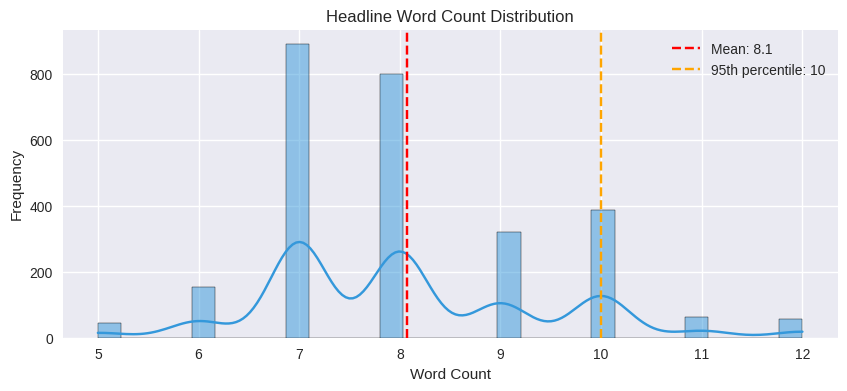

In [17]:
# ── Analyze word count in headlines ──────────────────────────────────────────
# This helps us choose max_seq_length for tokenization
# Too short = information loss; Too long = unnecessary padding

df["headline_word_count"] = df["Headline"].str.split().str.len()

print("Headline Word Count Statistics:")
print(df["headline_word_count"].describe())
print(f"95th percentile: {df['headline_word_count'].quantile(0.95):.0f} words")
print("-> We can safely use max_seq_length=128 to capture almost all headlines")

# Plot the distribution
plt.figure(figsize=(10, 4))
sns.histplot(df["headline_word_count"], bins=30, kde=True, color="#3498db")
plt.axvline(df["headline_word_count"].mean(), color="red", linestyle="--",
            label=f"Mean: {df['headline_word_count'].mean():.1f}")
plt.axvline(df["headline_word_count"].quantile(0.95), color="orange", linestyle="--",
            label=f"95th percentile: {df['headline_word_count'].quantile(0.95):.0f}")
plt.title("Headline Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("results/plots/headline_lengths.png", dpi=150)
plt.show()

## 🔢 Step 5: Numerical Feature Analysis

In [ ]:
# ── Explore Index_Change_Percent and Trading_Volume ──────────────────────────
# These numerical features will be used by the BiGRU model (Model 2)
# for Impact Level prediction via feature fusion

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Index Change Percent
sns.histplot(df["Index_Change_Percent"], bins=30, kde=True, ax=axes[0], color="#e67e22")
axes[0].set_title("Index Change Percent Distribution")
axes[0].set_xlabel("Index Change (%)")
axes[0].axvline(0, color="red", linestyle="--", label="Zero")
axes[0].legend()

# Trading Volume
sns.histplot(df["Trading_Volume"], bins=30, kde=True, ax=axes[1], color="#1abc9c")
axes[1].set_title("Trading Volume Distribution")
axes[1].set_xlabel("Volume")

plt.tight_layout()
plt.savefig("results/plots/numerical_features.png", dpi=150)
plt.show()

print("Index_Change_Percent stats:")
print(df["Index_Change_Percent"].describe())
print("
Trading_Volume stats:")
print(df["Trading_Volume"].describe())

In [ ]:
# ── Correlation between numerical features and Impact Level ──────────────────
# Check if Index_Change_Percent varies across impact levels (useful signal for BiGRU)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Impact_Level", y="Index_Change_Percent",
            order=["Low", "Medium", "High"],
            palette={"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"})
plt.title("Index Change % by Impact Level")
plt.xlabel("Impact Level")
plt.ylabel("Index Change (%)")
plt.savefig("results/plots/numerical_vs_impact.png", dpi=150)
plt.show()

## 💾 Step 6: Save Cleaned Dataset

In [ ]:
# ── Save the cleaned dataframe for use in all 3 model notebooks ─────────────
# This ensures consistent preprocessing across all models

df.to_csv("data/processed/financial_news_clean.csv", index=False)

print("Cleaned dataset saved to: data/processed/financial_news_clean.csv")
print(f"Final shape: {df.shape}")
print("
Column summary:")
print(df.describe(include="all").T[["count", "unique", "top", "freq"]].dropna())